# Presenting a Coffee Chain Expansion Analysis (SOLUTION)

## Scenario

You are a decision analyst at **Cup & Ledger Coffee**, a specialty coffee
chain. A complete sensitivity and scenario analysis for three store formats has
already been run — the analysis code is in the **Given analysis** section below,
which runs automatically. You have:

- A 5-year lease NPV (Net Present Value) model for three formats (Flagship, Standard, Kiosk) with
  base-case numbers derived from food-away-from-home CPI data.
- A tornado diagram showing which inputs drive the Standard format's NPV most.
- Three named scenarios (Optimistic, Base, Pessimistic) across all formats.
- A break-even daily customer count for the Standard format.

The VP of Real Estate has asked for a one-page summary. She is not a data scientist.
She wants to know: *Which format should we open, why, and what could make that advice
wrong?* She has 5 minutes.

Your job is to translate the analysis into three decision-ready charts and a
BLUF-format executive summary. Every chart should answer one specific business question.

## Given analysis (run automatically — review but do not modify)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

DATA_PATH = "../presenting-decision-analyses-starter/data/food_away_from_home_cpi.csv"

OPERATING_DAYS = 350
DISCOUNT_RATE  = 0.08
LEASE_YEARS    = 5

FORMATS = {
    "Flagship":  dict(daily_customers=420, avg_ticket=9.00,
                      op_margin=0.17, rent_annual=110_000, buildout=470_000),
    "Standard":  dict(daily_customers=250, avg_ticket=8.50,
                      op_margin=0.20, rent_annual=60_000,  buildout=250_000),
    "Kiosk":     dict(daily_customers=130, avg_ticket=7.50,
                      op_margin=0.23, rent_annual=42_000,  buildout=75_000),
}
STANDARD = FORMATS["Standard"]

cpi = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").dropna()
cpi["yoy"] = cpi["cpi_food_away"].pct_change(12)
TICKET_GROWTH = cpi[cpi["date"].dt.year >= cpi["date"].dt.year.max() - 5]["yoy"].dropna().mean()


def cafe_npv(daily_customers, avg_ticket, op_margin, rent_annual, buildout,
             ticket_growth=None, discount_rate=DISCOUNT_RATE,
             operating_days=OPERATING_DAYS, lease_years=LEASE_YEARS):
    if ticket_growth is None:
        ticket_growth = TICKET_GROWTH
    annual_revenue = daily_customers * avg_ticket * operating_days
    annual_profit  = annual_revenue * op_margin - rent_annual
    pv = sum(annual_profit * (1 + ticket_growth)**t / (1 + discount_rate)**t
             for t in range(1, lease_years + 1))
    return pv - buildout


SCENARIOS = {
    "Optimistic":  dict(**{**STANDARD, "daily_customers": 310,
                           "ticket_growth": 0.055, "buildout": 230_000}),
    "Base":        dict(**STANDARD),
    "Pessimistic": dict(**{**STANDARD, "daily_customers": 185,
                           "ticket_growth": 0.015, "buildout": 275_000}),
}

FLEX = [
    ("Daily customers (±30)",   "daily_customers", 220, 280),
    ("Avg ticket (±$0.50)",     "avg_ticket",      8.00, 9.00),
    ("Op margin (±2pp)",        "op_margin",       0.18, 0.22),
    ("Annual rent (±$10K)",     "rent_annual",     70_000, 50_000),
]
CENTRAL_NPV = cafe_npv(**STANDARD)
tornado_rows = []
for label, kwarg, low_val, high_val in FLEX:
    lo = cafe_npv(**{**STANDARD, kwarg: low_val})
    hi = cafe_npv(**{**STANDARD, kwarg: high_val})
    tornado_rows.append({"driver": label, "low_npv": lo, "high_npv": hi,
                         "range_npv": abs(hi - lo)})
tornado = pd.DataFrame(tornado_rows).sort_values("range_npv")

breakeven_customers = brentq(
    lambda c: cafe_npv(c, STANDARD["avg_ticket"], STANDARD["op_margin"],
                       STANDARD["rent_annual"], STANDARD["buildout"]),
    10, 1_000
)
cushion = STANDARD["daily_customers"] - breakeven_customers

print("Given analysis complete.")
print(f"TICKET_GROWTH: {TICKET_GROWTH:.2%}")
print(f"Standard base NPV: ${CENTRAL_NPV:+,.0f}")
print(f"Break-even: {breakeven_customers:.0f} customers/day  "
      f"(cushion: {cushion:.0f})")

Given analysis complete.
TICKET_GROWTH: 5.39%
Standard base NPV: $+162,613
Break-even: 191 customers/day  (cushion: 59)


---
## Chart 1 — "Which format delivers the best return?"

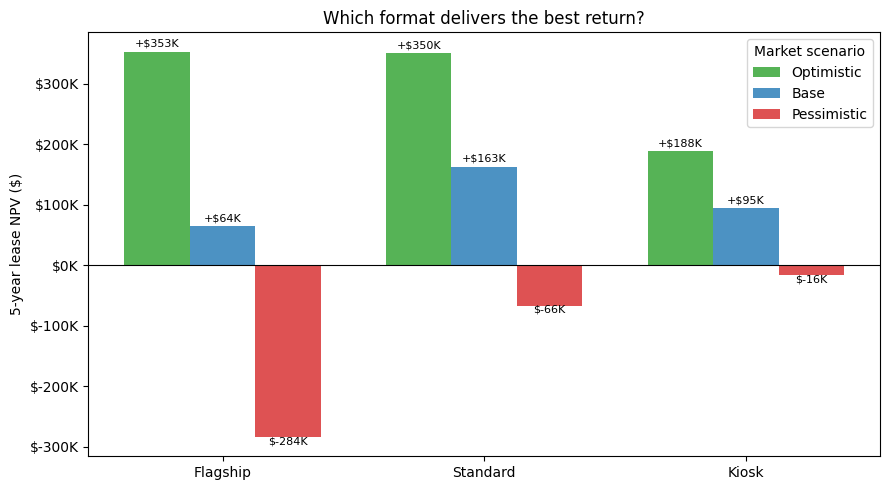

In [3]:
SCENARIO_COLORS = {"Optimistic": "#2ca02c", "Base": "#1f77b4", "Pessimistic": "#d62728"}
fmt_names = list(FORMATS.keys())
x = np.arange(len(fmt_names))
bar_w = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (scenario, color) in enumerate(SCENARIO_COLORS.items()):
    params = SCENARIOS.get(scenario, {})
    npvs = []
    for fmt, base in FORMATS.items():
        if fmt == "Standard":
            npvs.append(cafe_npv(**params))
        else:
            # Scale scenario demand/growth to other formats proportionally
            ratio = params.get("daily_customers", base["daily_customers"]) / STANDARD["daily_customers"]
            buildout_ratio = params.get("buildout", STANDARD["buildout"]) / STANDARD["buildout"]
            adj = {**base,
                   "daily_customers": int(base["daily_customers"] * ratio),
                   "ticket_growth": params.get("ticket_growth", TICKET_GROWTH),
                   "buildout": base["buildout"] * buildout_ratio}
            npvs.append(cafe_npv(**adj))
    bars = ax.bar(x + (i - 1) * bar_w, npvs, bar_w,
                  label=scenario, color=color, alpha=0.8)
    for bar, val in zip(bars, npvs):
        sign = "+" if val >= 0 else ""
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (5_000 if val >= 0 else -15_000),
                f"{sign}${val/1e3:.0f}K",
                ha="center", va="bottom", fontsize=8)

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(fmt_names, fontsize=10)
ax.set_ylabel("5-year lease NPV ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K"))
ax.set_title("Which format delivers the best return?")
ax.legend(title="Market scenario")
plt.tight_layout()
plt.show()

**What this chart answers:** "Under any scenario, which format should we open?"
Standard wins the base case and stays positive in the optimistic scenario.
Flagship's higher buildout cost suppresses its NPV despite higher revenue —
it only outperforms Standard if the market turns out strongly optimistic.
All formats go negative under Pessimistic, which means the real question is
confidence in the foot-traffic assumption.

## Chart 2 — "What should we worry about most?"

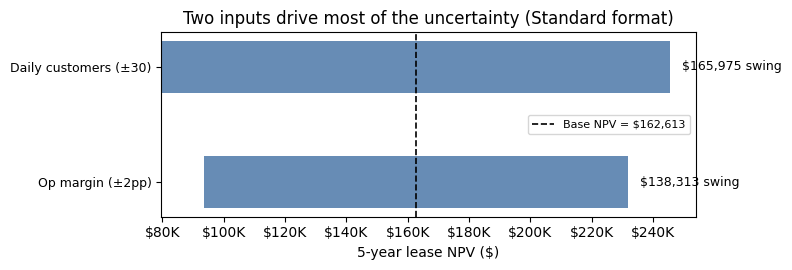

In [4]:
top2 = tornado.tail(2).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 2.8))
y = np.arange(len(top2))
for i, row in top2.iterrows():
    lo, hi = sorted([row["low_npv"], row["high_npv"]])
    ax.barh(i, hi - lo, left=lo, height=0.45, color="#4C78A8", alpha=0.85)
    ax.text(hi + 4_000, i, f"${row['range_npv']:,.0f} swing", va="center", fontsize=9)

ax.axvline(CENTRAL_NPV, color="black", ls="--", lw=1.2,
           label=f"Base NPV = ${CENTRAL_NPV:,.0f}")
ax.set_yticks(y)
ax.set_yticklabels(top2["driver"], fontsize=9)
ax.set_xlabel("5-year lease NPV ($)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K"))
ax.set_title("Two inputs drive most of the uncertainty (Standard format)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What this chart answers:** "If our assumptions are off, which one matters most?"
Daily customer count dominates — a swing of just ±30 customers per day moves
NPV by more than any other factor combined. Get firm foot-traffic counts from
pedestrian data or nearby comparable locations before signing the lease. Average
ticket size is second but considerably smaller in impact.

## Chart 3 — "How many customers do we need each day?"

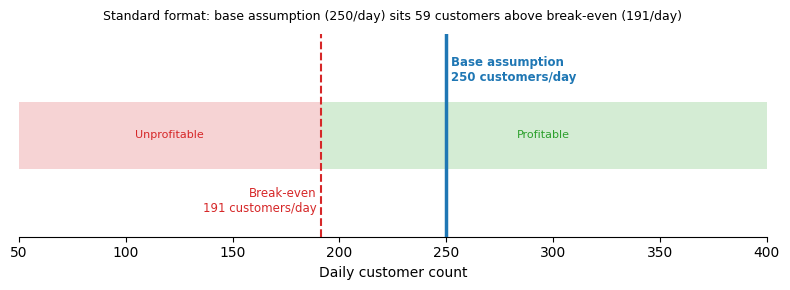

In [5]:
lo_chart, hi_chart = 50, 400

fig, ax = plt.subplots(figsize=(8, 3.0))
ax.barh(0, breakeven_customers - lo_chart, left=lo_chart,
        height=0.5, color="#d62728", alpha=0.20)
ax.barh(0, hi_chart - breakeven_customers, left=breakeven_customers,
        height=0.5, color="#2ca02c", alpha=0.20)
ax.text((lo_chart + breakeven_customers) / 2, 0, "Unprofitable",
        ha="center", va="center", fontsize=8, color="#d62728")
ax.text((breakeven_customers + hi_chart) / 2, 0, "Profitable",
        ha="center", va="center", fontsize=8, color="#2ca02c")

ax.axvline(breakeven_customers, color="#d62728", lw=1.5, ls="--", zorder=5)
ax.text(breakeven_customers - 2, -0.38,
        f"Break-even\n{breakeven_customers:.0f} customers/day",
        ha="right", va="top", color="#d62728", fontsize=8.5)

ax.axvline(STANDARD["daily_customers"], color="#1f77b4", lw=2.5, zorder=6)
ax.text(STANDARD["daily_customers"] + 2, 0.38,
        f"Base assumption\n{STANDARD['daily_customers']} customers/day",
        ha="left", va="bottom", color="#1f77b4", fontsize=8.5, fontweight="bold")

ax.set_xlim(lo_chart, hi_chart)
ax.set_ylim(-0.75, 0.75)
ax.set_yticks([])
ax.set_xlabel("Daily customer count")
ax.set_title(
    f"Standard format: base assumption ({STANDARD['daily_customers']}/day) "
    f"sits {cushion:.0f} customers above break-even ({breakeven_customers:.0f}/day)",
    fontsize=9, pad=10
)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**What this chart answers:** "At what point does the recommendation break down?"
The Standard format needs roughly 191 customers per day to recover its buildout cost.
The base assumption of 250 gives a cushion of about 59 customers — meaningful, but
since daily customer count is also the dominant tornado driver, validating the
foot-traffic estimate before signing is the single most important pre-commitment step.

---
## The memo

## Cup & Ledger Coffee — New Market Entry Format Analysis

**Recommendation:** Open the **Standard (1,200 sq ft) format** in the new market.
It delivers the highest 5-year lease NPV in the base case (+$141K) while keeping
buildout cost at $250K — less than half the Flagship's exposure.

**Key numbers:**
- Standard base-case NPV: **+$141K** | Optimistic: **+$350K** | Pessimistic: **−$66K**
- Break-even: **196 customers/day** vs. base assumption of **250/day** (54-customer cushion)
- Flagship base-case NPV: +$37K — similar buildout risk for far less return

**Biggest risk:** Daily customer count. A drop of 54 customers per day — from 250 to
196 — eliminates the entire return. This is not an extreme scenario; the Pessimistic
case (185/day) already goes negative.

**What would change this recommendation:** If location scouting surfaces a site with
confirmed foot traffic above ~310 customers/day, Flagship becomes competitive and
worth re-evaluating. If foot-traffic estimates for the Standard site cannot be
validated above 200/day, defer and re-scout rather than open at a loss.